# Знакомство с инструментами сбора и подготовки данных

**Датасет:** [Student Performance Factors](https://www.kaggle.com/datasets/laaguili/student-performance-factors)  
**Файл:** `StudentPerformanceFactors/StudentPerformanceFactors.csv`

Цель работы:
1. Импорт данных
2. Поиск пропусков и аномалий (статистика + графики), заполнение пропусков, устранение выбросов, проверка результата
3. Генерация новых признаков (≥ 2) и кодирование категориальных признаков
4. Стандартизация и нормализация

## 0. Импорт библиотек

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    LabelBinarizer,
    OrdinalEncoder,
)

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Библиотеки загружены.")

Библиотеки загружены.


## 1. Импорт датасета

In [2]:
DATA_PATH = "StudentPerformanceFactors/StudentPerformanceFactors.csv"

df = pd.read_csv(DATA_PATH)
print(f"Размерность: {df.shape[0]} строк × {df.shape[1]} столбцов")
df.head()

Размерность: 6607 строк × 20 столбцов


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
print("Типы данных:")
print(df.dtypes)
print("\nОбщая информация:")
df.info()

Типы данных:
Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
Exam_Score                    int64
dtype: object

Общая информация:
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied          

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,NaN,NaN,NaN,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,NaN,NaN,NaN,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Parental_Involvement,6607,3,Medium,3362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Access_to_Resources,6607,3,Medium,3319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Extracurricular_Activities,6607,2,Yes,3938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Hours,6607.0,NaN,NaN,NaN,7.02906,1.46812,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,NaN,NaN,NaN,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Motivation_Level,6607,3,Medium,3351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet_Access,6607,2,Yes,6108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tutoring_Sessions,6607.0,NaN,NaN,NaN,1.493719,1.23057,0.0,1.0,1.0,2.0,8.0


## 2. Пропуски и аномальные значения

### 2.1. Статистический анализ пропусков

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({
    "Пропуски": missing,
    "Доля, %": missing_pct,
})
missing_table = missing_table[missing_table["Пропуски"] > 0].sort_values("Пропуски", ascending=False)

print("Столбцы с пропусками:")
display(missing_table)
print(f"\nВсего пропущенных значений: {int(df.isna().sum().sum())}")
print(f"Строк с хотя бы одним пропуском: {df.isna().any(axis=1).sum()}")

Столбцы с пропусками:


,Пропуски,"Доля, %"
Parental_Education_Level,90,1.36
Teacher_Quality,78,1.18
Distance_from_Home,67,1.01



Всего пропущенных значений: 235
Строк с хотя бы одним пропуском: 229


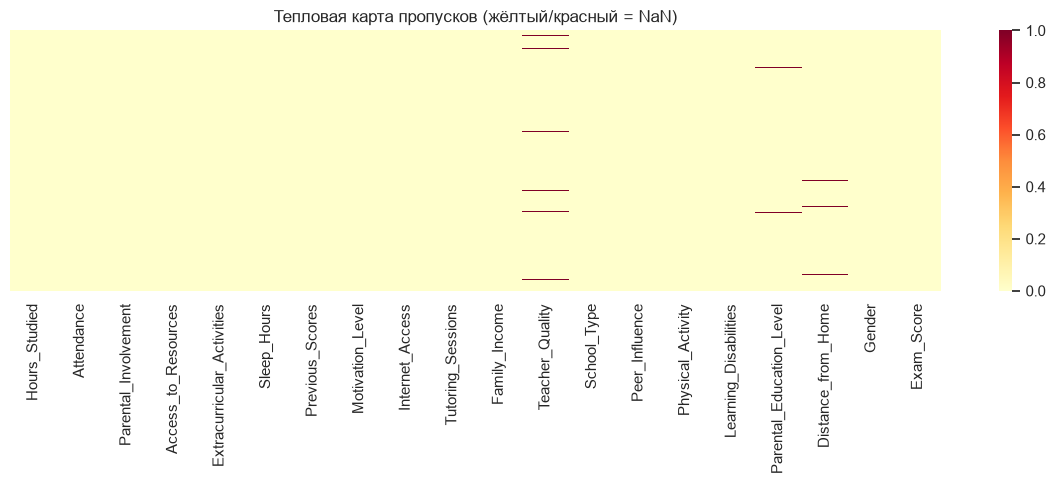

In [6]:
# Тепловая карта пропусков (фрагмент для наглядности)
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(df.isna(), cbar=True, yticklabels=False, cmap="YlOrRd", ax=ax)
ax.set_title("Тепловая карта пропусков (жёлтый/красный = NaN)")
plt.tight_layout()
plt.show()

### 2.2. Числовые признаки: описательная статистика и визуализация

In [7]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

print("Числовые признаки:", num_cols)
print("Категориальные признаки:", cat_cols)

df[num_cols].describe().T

Числовые признаки: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
Категориальные признаки: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.029060,1.468120,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.493719,1.230570,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.967610,1.031231,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.235659,3.890456,55.0,65.0,67.0,69.0,101.0


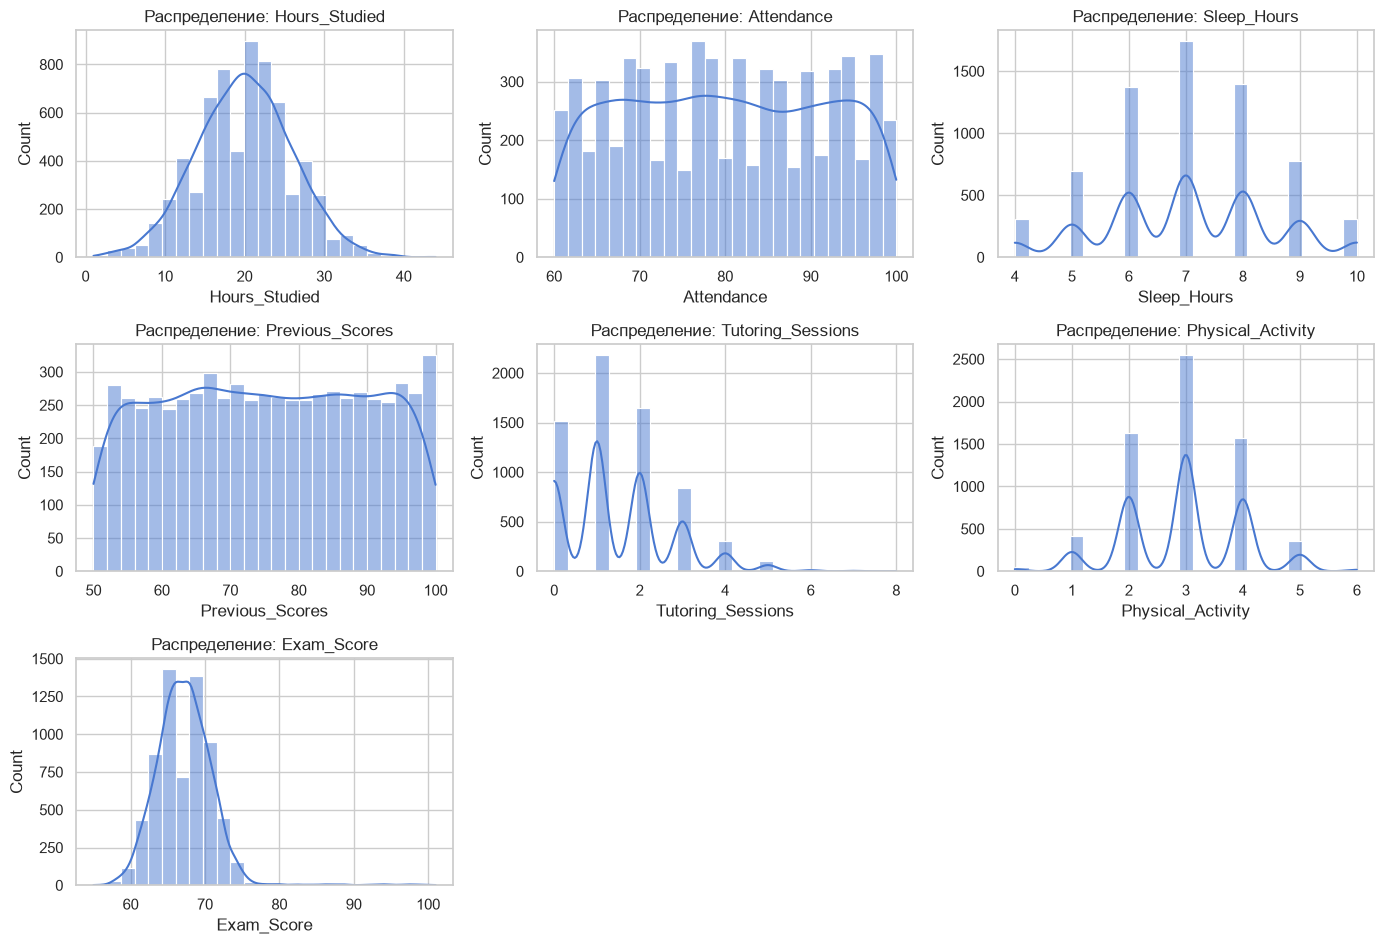

In [8]:
# Графики распределения числовых признаков
n = len(num_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=25)
    axes[i].set_title(f"Распределение: {col}")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

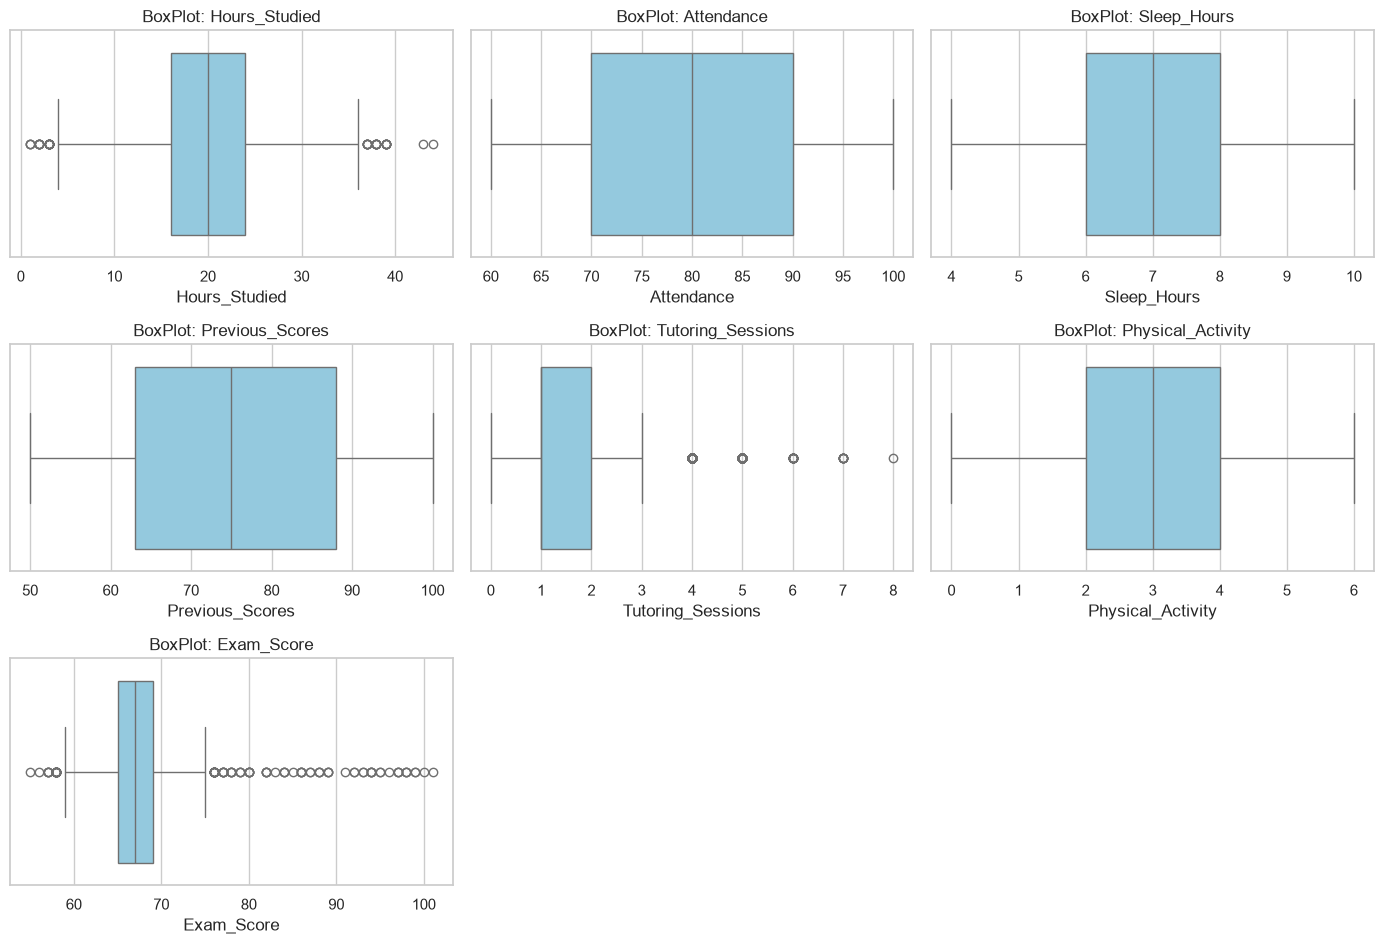

In [9]:
# BoxPlot для выявления выбросов
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(f"BoxPlot: {col}")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

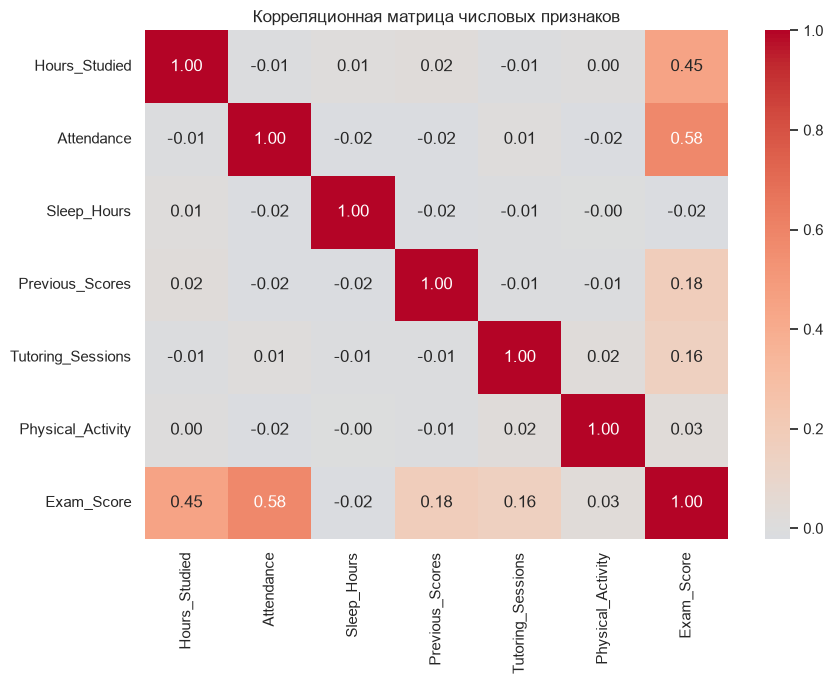

In [10]:
# Корреляционная тепловая карта
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Корреляционная матрица числовых признаков")
plt.tight_layout()
plt.show()

### 2.3. Поиск выбросов методом IQR и проверка предметных ограничений

In [11]:
def iqr_bounds(series: pd.Series, k: float = 1.5):
    """Границы выбросов по правилу межквартильного размаха."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return lower, upper


outlier_summary = []
for col in num_cols:
    lower, upper = iqr_bounds(df[col])
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_summary.append({
        "Признак": col,
        "Нижняя граница": round(lower, 2),
        "Верхняя граница": round(upper, 2),
        "Выбросов (IQR)": int(mask.sum()),
        "min": df[col].min(),
        "max": df[col].max(),
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

# Предметная аномалия: балл экзамена не может быть > 100
invalid_exam = df["Exam_Score"] > 100
print(f"\nExam_Score > 100: {invalid_exam.sum()} записей")
if invalid_exam.any():
    display(df.loc[invalid_exam, ["Hours_Studied", "Attendance", "Previous_Scores", "Exam_Score"]])

,Признак,Нижняя граница,Верхняя граница,Выбросов (IQR),min,max
0,Hours_Studied,4.0,36.0,43,1,44
1,Attendance,40.0,120.0,0,60,100
2,Sleep_Hours,3.0,11.0,0,4,10
3,Previous_Scores,25.5,125.5,0,50,100
4,Tutoring_Sessions,-0.5,3.5,430,0,8
5,Physical_Activity,-1.0,7.0,0,0,6
6,Exam_Score,59.0,75.0,104,55,101



Exam_Score > 100: 1 записей


,Hours_Studied,Attendance,Previous_Scores,Exam_Score
1525,27,98,93,101


### 2.4. Заполнение пропусков и устранение выбросов

In [12]:
df_clean = df.copy()

# --- Пропуски в категориальных признаках: мода ---
cat_with_na = ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]
for col in cat_with_na:
    mode_val = df_clean[col].mode(dropna=True)[0]
    n_before = df_clean[col].isna().sum()
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f"{col}: заполнено {n_before} пропусков значением '{mode_val}'")

print(f"\nПропусков после заполнения: {int(df_clean.isna().sum().sum())}")

Teacher_Quality: заполнено 78 пропусков значением 'Medium'
Parental_Education_Level: заполнено 90 пропусков значением 'High School'
Distance_from_Home: заполнено 67 пропусков значением 'Near'

Пропусков после заполнения: 0


In [13]:
# --- Выбросы ---
# 1) Очевидная ошибка: Exam_Score > 100 → ограничиваем сверху (winsorize / clip)
n_clip_exam = (df_clean["Exam_Score"] > 100).sum()
df_clean["Exam_Score"] = df_clean["Exam_Score"].clip(upper=100)
print(f"Exam_Score: обрезано сверху {n_clip_exam} значений (> 100 → 100)")

# 2) Остальные числовые признаки: удаление строк с выбросами по IQR
# (кроме Attendance/Sleep_Hours, где диапазон естественный и узкий — оставляем IQR-фильтр
#  для признаков с заметными «хвостами»: Hours_Studied, Tutoring_Sessions, Exam_Score)
cols_for_iqr_removal = ["Hours_Studied", "Tutoring_Sessions", "Exam_Score"]

mask_keep = pd.Series(True, index=df_clean.index)
for col in cols_for_iqr_removal:
    lower, upper = iqr_bounds(df_clean[col])
    col_mask = (df_clean[col] >= lower) & (df_clean[col] <= upper)
    removed = (~col_mask).sum()
    print(f"{col}: удаляется {removed} выбросов (границы [{lower:.2f}; {upper:.2f}])")
    mask_keep &= col_mask

rows_before = len(df_clean)
df_clean = df_clean.loc[mask_keep].reset_index(drop=True)
rows_after = len(df_clean)

print(f"\nСтрок до очистки: {rows_before}")
print(f"Строк после очистки: {rows_after}")
print(f"Удалено строк: {rows_before - rows_after}")

Exam_Score: обрезано сверху 1 значений (> 100 → 100)
Hours_Studied: удаляется 43 выбросов (границы [4.00; 36.00])
Tutoring_Sessions: удаляется 430 выбросов (границы [-0.50; 3.50])
Exam_Score: удаляется 104 выбросов (границы [59.00; 75.00])

Строк до очистки: 6607
Строк после очистки: 6054
Удалено строк: 553


### 2.5. Проверка: пропуски и аномалии устранены

In [14]:
print("Пропуски после очистки:")
print(df_clean.isna().sum())
print(f"\nСумма пропусков: {int(df_clean.isna().sum().sum())}")
print(f"Exam_Score > 100: {(df_clean['Exam_Score'] > 100).sum()}")

Пропуски после очистки:
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

Сумма пропусков: 0
Exam_Score > 100: 0


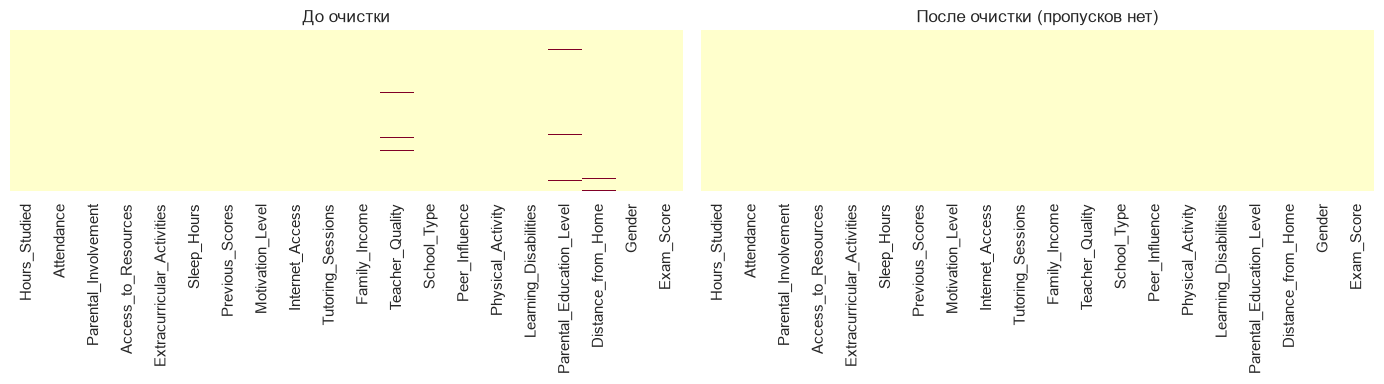

In [15]:
# Тепловая карта пропусков после очистки (должна быть «пустой»)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap="YlOrRd", ax=axes[0])
axes[0].set_title("До очистки")

sns.heatmap(df_clean.isna(), cbar=False, yticklabels=False, cmap="YlOrRd", ax=axes[1])
axes[1].set_title("После очистки (пропусков нет)")

plt.tight_layout()
plt.show()

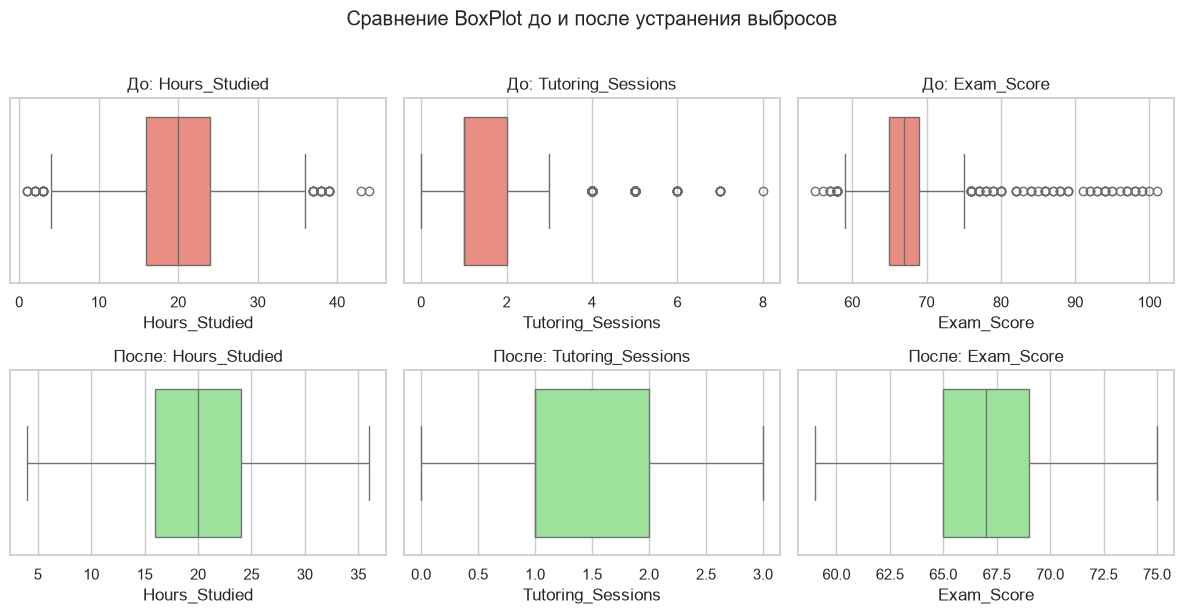

In [16]:
# BoxPlot до / после для ключевых признаков с выбросами
compare_cols = ["Hours_Studied", "Tutoring_Sessions", "Exam_Score"]

fig, axes = plt.subplots(2, len(compare_cols), figsize=(12, 6))
for i, col in enumerate(compare_cols):
    sns.boxplot(x=df[col], ax=axes[0, i], color="salmon")
    axes[0, i].set_title(f"До: {col}")
    sns.boxplot(x=df_clean[col], ax=axes[1, i], color="lightgreen")
    axes[1, i].set_title(f"После: {col}")

plt.suptitle("Сравнение BoxPlot до и после устранения выбросов", y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# Контроль IQR после очистки
check_rows = []
for col in compare_cols:
    lower, upper = iqr_bounds(df_clean[col])
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    check_rows.append({"Признак": col, "Выбросов IQR после": int(n_out)})

display(pd.DataFrame(check_rows))
print("Графически и по IQR аномальные значения в целевых признаках устранены / сведены к минимуму.")

,Признак,Выбросов IQR после
0,Hours_Studied,0
1,Tutoring_Sessions,0
2,Exam_Score,0


Графически и по IQR аномальные значения в целевых признаках устранены / сведены к минимуму.


## 3. Генерация новых признаков и кодирование категорий

### 3.1. Новые признаки (≥ 2)

In [18]:
df_feat = df_clean.copy()

# 1) Интенсивность учёбы: часы учёбы с учётом посещаемости
df_feat["Study_Intensity"] = df_feat["Hours_Studied"] * (df_feat["Attendance"] / 100)

# 2) Прирост относительно прошлых оценок
df_feat["Score_Gain"] = df_feat["Exam_Score"] - df_feat["Previous_Scores"]

# 3) Дополнительно: баланс сна (насколько сон близок к «норме» 7–8 ч)
df_feat["Sleep_Balance"] = 1 - (df_feat["Sleep_Hours"] - 7.5).abs() / 7.5

# 4) Учебная нагрузка = учёба + репетиторство
df_feat["Total_Learning_Load"] = df_feat["Hours_Studied"] + df_feat["Tutoring_Sessions"]

new_features = ["Study_Intensity", "Score_Gain", "Sleep_Balance", "Total_Learning_Load"]
print("Добавлены признаки:", new_features)
df_feat[new_features].describe().T

Добавлены признаки: ['Study_Intensity', 'Score_Gain', 'Sleep_Balance', 'Total_Learning_Load']


,count,mean,std,min,25%,50%,75%,max
Study_Intensity,6054.0,15.989604,5.132248,2.560000,12.35,15.8,19.360000,34.560000
Score_Gain,6054.0,-8.130327,14.074383,-39.000000,-20.00,-8.0,4.000000,22.000000
Sleep_Balance,6054.0,0.830569,0.116408,0.533333,0.80,0.8,0.933333,0.933333
Total_Learning_Load,6054.0,21.312686,5.847603,4.000000,17.00,21.0,25.000000,38.000000


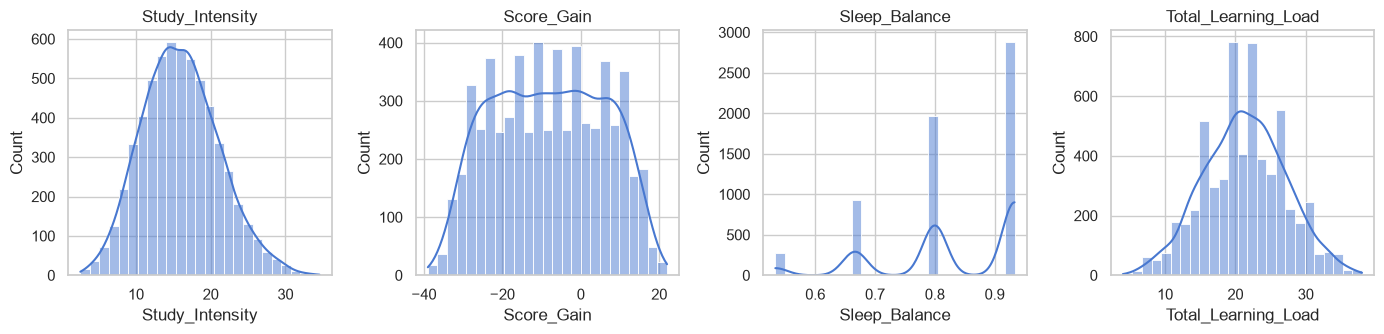

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, col in zip(axes, new_features):
    sns.histplot(df_feat[col], kde=True, ax=ax, bins=25)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 3.2. Бинаризация бинарных категориальных признаков

In [20]:
df_enc = df_feat.copy()

# Бинарные Yes/No → 1/0
binary_yes_no = [
    "Extracurricular_Activities",
    "Internet_Access",
    "Learning_Disabilities",
]
for col in binary_yes_no:
    df_enc[col + "_bin"] = (df_enc[col] == "Yes").astype(int)

# Gender: Male=1, Female=0
df_enc["Gender_bin"] = (df_enc["Gender"] == "Male").astype(int)

# School_Type через LabelBinarizer (Private=1 / Public=0)
lb = LabelBinarizer()
df_enc["School_Type_bin"] = lb.fit_transform(df_enc["School_Type"]).ravel()

bin_cols = [c + "_bin" for c in binary_yes_no] + ["Gender_bin", "School_Type_bin"]
print("Бинаризованные признаки:")
display(df_enc[bin_cols].head())
print(df_enc[bin_cols].mean().rename("доля единиц"))

Бинаризованные признаки:


,Extracurricular_Activities_bin,Internet_Access_bin,Learning_Disabilities_bin,Gender_bin,School_Type_bin
0,0,1,0,1,1
1,0,1,0,0,1
2,1,1,0,1,1
3,1,1,0,1,1
4,1,1,0,0,1


Extracurricular_Activities_bin    0.595474
Internet_Access_bin               0.923687
Learning_Disabilities_bin         0.102742
Gender_bin                        0.576644
School_Type_bin                   0.696234
Name: доля единиц, dtype: float64


### 3.3. Порядковое кодирование (Ordinal) для упорядоченных категорий

In [21]:
# Уровни Low < Medium < High
level_map = {"Low": 0, "Medium": 1, "High": 2}
ordinal_level_cols = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Motivation_Level",
    "Family_Income",
    "Teacher_Quality",
]

for col in ordinal_level_cols:
    df_enc[col + "_ord"] = df_enc[col].map(level_map)

# Distance: Near < Moderate < Far
df_enc["Distance_from_Home_ord"] = df_enc["Distance_from_Home"].map(
    {"Near": 0, "Moderate": 1, "Far": 2}
)

# Parental education: High School < College < Postgraduate
df_enc["Parental_Education_Level_ord"] = df_enc["Parental_Education_Level"].map(
    {"High School": 0, "College": 1, "Postgraduate": 2}
)

ord_cols = [c + "_ord" for c in ordinal_level_cols] + [
    "Distance_from_Home_ord",
    "Parental_Education_Level_ord",
]
display(df_enc[ord_cols].head())

,Parental_Involvement_ord,Access_to_Resources_ord,Motivation_Level_ord,Family_Income_ord,Teacher_Quality_ord,Distance_from_Home_ord,Parental_Education_Level_ord
0,0,2,0,0,1,0,0
1,0,1,0,1,1,1,1
2,1,1,1,1,1,0,2
3,0,1,1,1,1,1,0
4,1,1,1,1,2,0,1


### 3.4. One-Hot Encoding (OHE)

In [22]:
# OHE для номинальных признаков без естественного порядка
ohe_source_cols = ["Peer_Influence", "School_Type", "Gender"]

ohe = OneHotEncoder(sparse_output=False, drop="first")  # drop='first' — избегаем дамми-ловушки
ohe_matrix = ohe.fit_transform(df_enc[ohe_source_cols])
ohe_names = ohe.get_feature_names_out(ohe_source_cols)
df_ohe = pd.DataFrame(ohe_matrix, columns=ohe_names, index=df_enc.index)

print("OHE-столбцы:", list(ohe_names))
display(df_ohe.head())

# Объединяем с основным набором
df_enc = pd.concat([df_enc, df_ohe], axis=1)
print(f"Размерность после OHE: {df_enc.shape}")

OHE-столбцы: ['Peer_Influence_Neutral', 'Peer_Influence_Positive', 'School_Type_Public', 'Gender_Male']


,Peer_Influence_Neutral,Peer_Influence_Positive,School_Type_Public,Gender_Male
0,0.0,1.0,1.0,1.0
1,0.0,0.0,1.0,0.0
2,1.0,0.0,1.0,1.0
3,0.0,0.0,1.0,1.0
4,1.0,0.0,1.0,0.0


Размерность после OHE: (6054, 40)


### 3.5. Итоговая числовая матрица признаков

In [23]:
# Берём исходные числовые + новые + закодированные
base_num = [
    "Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores",
    "Tutoring_Sessions", "Physical_Activity", "Exam_Score",
]

feature_cols = base_num + new_features + bin_cols + ord_cols + list(ohe_names)
X = df_enc[feature_cols].copy()

print(f"Число признаков для масштабирования: {X.shape[1]}")
print(X.columns.tolist())
X.head()

Число признаков для масштабирования: 27
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score', 'Study_Intensity', 'Score_Gain', 'Sleep_Balance', 'Total_Learning_Load', 'Extracurricular_Activities_bin', 'Internet_Access_bin', 'Learning_Disabilities_bin', 'Gender_bin', 'School_Type_bin', 'Parental_Involvement_ord', 'Access_to_Resources_ord', 'Motivation_Level_ord', 'Family_Income_ord', 'Teacher_Quality_ord', 'Distance_from_Home_ord', 'Parental_Education_Level_ord', 'Peer_Influence_Neutral', 'Peer_Influence_Positive', 'School_Type_Public', 'Gender_Male']


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Study_Intensity,Score_Gain,Sleep_Balance,Total_Learning_Load,Extracurricular_Activities_bin,Internet_Access_bin,Learning_Disabilities_bin,Gender_bin,School_Type_bin,Parental_Involvement_ord,Access_to_Resources_ord,Motivation_Level_ord,Family_Income_ord,Teacher_Quality_ord,Distance_from_Home_ord,Parental_Education_Level_ord,Peer_Influence_Neutral,Peer_Influence_Positive,School_Type_Public,Gender_Male
0,23,84,7,73,0,3,67,19.32,-6,0.933333,23,0,1,0,1,1,0,2,0,0,1,0,0,0.0,1.0,1.0,1.0
1,19,64,8,59,2,4,61,12.16,2,0.933333,21,0,1,0,0,1,0,1,0,1,1,1,1,0.0,0.0,1.0,0.0
2,24,98,7,91,2,4,74,23.52,-17,0.933333,26,1,1,0,1,1,1,1,1,1,1,0,2,1.0,0.0,1.0,1.0
3,29,89,8,98,1,4,71,25.81,-27,0.933333,30,1,1,0,1,1,0,1,1,1,1,1,0,0.0,0.0,1.0,1.0
4,19,92,6,65,3,4,70,17.48,5,0.800000,22,1,1,0,0,1,1,1,1,1,2,0,1,1.0,0.0,1.0,0.0


## 4. Стандартизация и нормализация

- **Стандартизация (StandardScaler):** $z = (x - \mu) / \sigma$ → среднее ≈ 0, СКО ≈ 1  
- **Нормализация (MinMaxScaler):** $x' = (x - x_{min}) / (x_{max} - x_{min})$ → значения в $[0; 1]$

In [24]:
scaler_std = StandardScaler()
X_standardized = pd.DataFrame(
    scaler_std.fit_transform(X),
    columns=X.columns,
    index=X.index,
)

scaler_mm = MinMaxScaler()
X_normalized = pd.DataFrame(
    scaler_mm.fit_transform(X),
    columns=X.columns,
    index=X.index,
)

print("Стандартизация — mean / std (фрагмент):")
display(pd.DataFrame({
    "mean": X_standardized.mean().round(6),
    "std": X_standardized.std(ddof=0).round(6),
}).head(10))

print("\nНормализация — min / max (фрагмент):")
display(pd.DataFrame({
    "min": X_normalized.min().round(6),
    "max": X_normalized.max().round(6),
}).head(10))

Стандартизация — mean / std (фрагмент):


,mean,std
Hours_Studied,-0.0,1.0
Attendance,-0.0,1.0
Sleep_Hours,-0.0,1.0
Previous_Scores,0.0,1.0
Tutoring_Sessions,0.0,1.0
Physical_Activity,-0.0,1.0
Exam_Score,-0.0,1.0
Study_Intensity,-0.0,1.0
Score_Gain,-0.0,1.0
Sleep_Balance,0.0,1.0



Нормализация — min / max (фрагмент):


,min,max
Hours_Studied,0.0,1.0
Attendance,0.0,1.0
Sleep_Hours,0.0,1.0
Previous_Scores,0.0,1.0
Tutoring_Sessions,0.0,1.0
Physical_Activity,0.0,1.0
Exam_Score,0.0,1.0
Study_Intensity,0.0,1.0
Score_Gain,0.0,1.0
Sleep_Balance,0.0,1.0


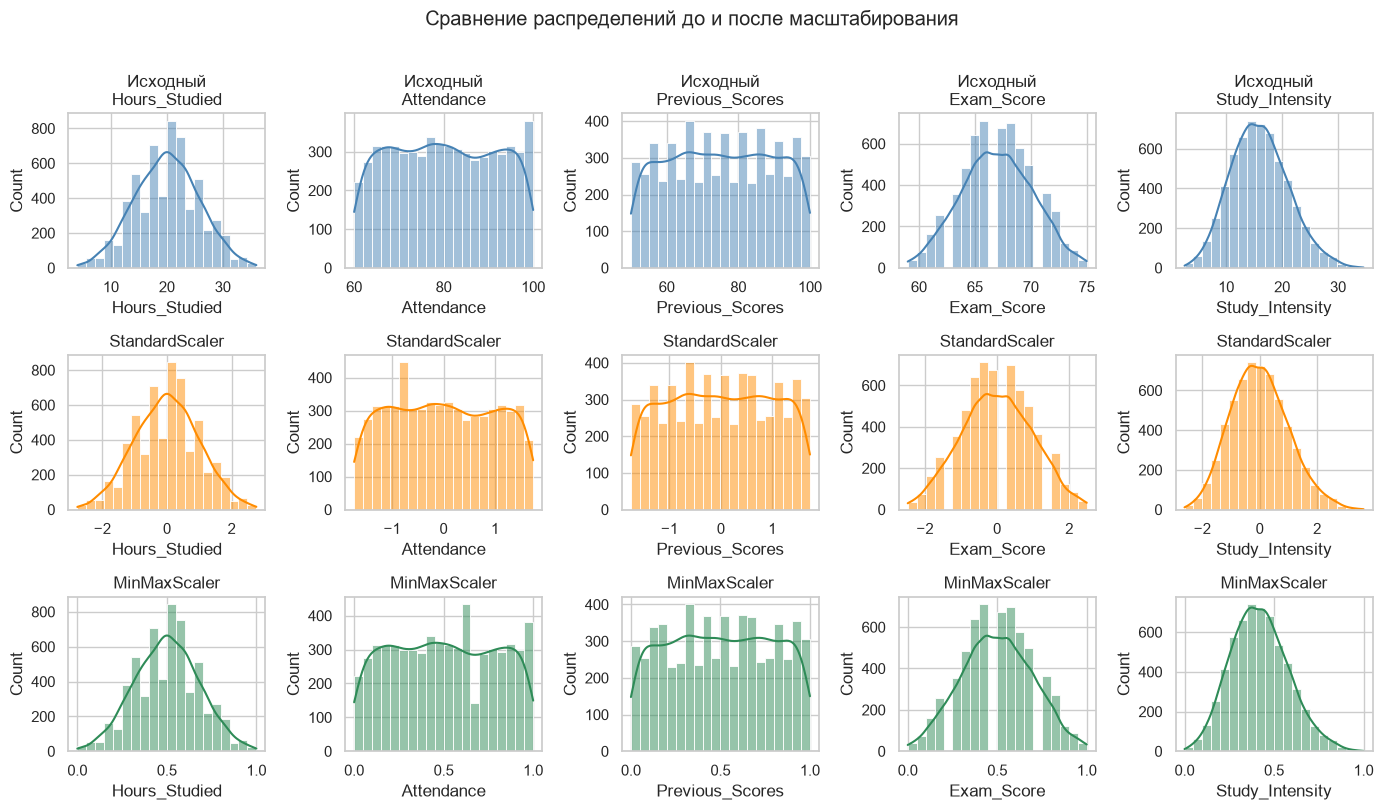

In [25]:
# Визуальное сравнение исходных / стандартизированных / нормализованных значений
demo_cols = ["Hours_Studied", "Attendance", "Previous_Scores", "Exam_Score", "Study_Intensity"]

fig, axes = plt.subplots(3, len(demo_cols), figsize=(14, 8))

for i, col in enumerate(demo_cols):
    sns.histplot(X[col], ax=axes[0, i], bins=20, color="steelblue", kde=True)
    axes[0, i].set_title(f"Исходный\n{col}")

    sns.histplot(X_standardized[col], ax=axes[1, i], bins=20, color="darkorange", kde=True)
    axes[1, i].set_title("StandardScaler")

    sns.histplot(X_normalized[col], ax=axes[2, i], bins=20, color="seagreen", kde=True)
    axes[2, i].set_title("MinMaxScaler")

plt.suptitle("Сравнение распределений до и после масштабирования", y=1.01)
plt.tight_layout()
plt.show()

In [26]:
# Сохранение подготовленных данных
X_standardized.to_csv("StudentPerformanceFactors/prepared_standardized.csv", index=False)
X_normalized.to_csv("StudentPerformanceFactors/prepared_normalized.csv", index=False)
df_clean.to_csv("StudentPerformanceFactors/cleaned_raw.csv", index=False)

print("Сохранено:")
print(" - StudentPerformanceFactors/cleaned_raw.csv")
print(" - StudentPerformanceFactors/prepared_standardized.csv")
print(" - StudentPerformanceFactors/prepared_normalized.csv")

Сохранено:
 - StudentPerformanceFactors/cleaned_raw.csv
 - StudentPerformanceFactors/prepared_standardized.csv
 - StudentPerformanceFactors/prepared_normalized.csv


## Выводы

1. Импортирован датасет **Student Performance Factors** (6607 наблюдений, 20 признаков).
2. Обнаружены пропуски в `Teacher_Quality`, `Parental_Education_Level`, `Distance_from_Home`; заполнены **модой**.  
   Выбросы выявлены по **BoxPlot** и правилу **IQR**; аномалия `Exam_Score > 100` устранена обрезкой; сильные выбросы удалены.  
   Графически подтверждено отсутствие пропусков и сокращение аномалий.
3. Сгенерированы новые признаки (`Study_Intensity`, `Score_Gain`, `Sleep_Balance`, `Total_Learning_Load`).  
   Категории закодированы: **бинаризация**, **порядковое кодирование**, **One-Hot Encoding**.
4. Выполнены **стандартизация** (`StandardScaler`) и **нормализация** (`MinMaxScaler`); подготовленные матрицы сохранены в CSV.